<a href="https://colab.research.google.com/github/Keshabbu/Datascience/blob/main/COMPLETE_VERSION_DATA_HANDELING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HANDELING THE THE MISSING VALUES/INBALANCE/FEATURE SCALING  IN THE DATASET

In [ ]:
import pandas as pd
import numpy as np

# Sample DataFrame with missing values
data = {
    'Age': [25, 30, np.nan, 22, 28, np.nan, 35],
    'Salary': [50000, 60000, 55000, np.nan, 65000, 70000, np.nan],
    'Department': ['HR', 'IT', 'IT', 'Finance', np.nan, 'HR', 'Finance']
}

df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)


Original DataFrame:
    Age   Salary Department
0  25.0  50000.0         HR
1  30.0  60000.0         IT
2   NaN  55000.0         IT
3  22.0      NaN    Finance
4  28.0  65000.0        NaN
5   NaN  70000.0         HR
6  35.0      NaN    Finance


In [ ]:
df

,Age,Salary,Department
0,25.0,50000.0,HR
1,30.0,60000.0,IT
2,NaN,55000.0,IT
3,22.0,NaN,Finance
4,28.0,65000.0,NaN
5,NaN,70000.0,HR
6,35.0,NaN,Finance


In [ ]:
df.isnull().sum()

,0
Age,2
Salary,2
Department,1


In [ ]:
df.shape

(7, 3)

In [ ]:
df.size

21

#MEAN VALUES IMPUTATION TECHNIQUE

In [ ]:
df['Age'].mean()

np.float64(28.0)

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [ ]:
df['Age']

,Age
0,25.0
1,30.0
2,28.0
3,22.0
4,28.0
5,28.0
6,35.0


#FOR CATEGORICAL MODE VALUE IMPUTATION TECHNIQUE

In [ ]:
df['Department'].mode()

,Department
0,Finance
1,HR
2,IT


In [ ]:
pd.Categorical(df['Department'])

['HR', 'IT', 'IT', 'Finance', NaN, 'HR', 'Finance']
Categories (3, object): ['Finance', 'HR', 'IT']

In [ ]:
df['Department'].unique()

array(['HR', 'IT', 'Finance', nan], dtype=object)

In [ ]:
mode_department = df['Department'].mode()[0]

In [ ]:
df['Department'] = df['Department'].fillna(mode_department)

In [ ]:
df['Department']

,Department
0,HR
1,IT
2,IT
3,Finance
4,Finance
5,HR
6,Finance


In [ ]:
df

,Age,Salary,Department
0,25.0,50000.0,HR
1,30.0,60000.0,IT
2,28.0,55000.0,IT
3,22.0,NaN,Finance
4,28.0,65000.0,Finance
5,28.0,70000.0,HR
6,35.0,NaN,Finance


#MEDIAN VALUE IMPUTATION TECHNIQUE

In [ ]:
df['Salary'].median()

60000.0

In [ ]:
df['Salary'] = df['Salary'].fillna(df['Salary'].median())

In [ ]:
df['Salary']

,Salary
0,50000.0
1,60000.0
2,55000.0
3,60000.0
4,65000.0
5,70000.0
6,60000.0


#DELETE COLUMN

In [ ]:
df.dropna(axis=1)

,Age,Salary,Department
0,25.0,50000.0,HR
1,30.0,60000.0,IT
2,28.0,55000.0,IT
3,22.0,60000.0,Finance
4,28.0,65000.0,Finance
5,28.0,70000.0,HR
6,35.0,60000.0,Finance


#HANDELING THE OUTLIRES BY IQR(INTERQUARTILE RANGE) TECHNIQUE

In [ ]:
import numpy as np

In [ ]:
Q1 = df['Salary'].quantile(0.25)

In [ ]:
Q3 = df['Salary'].quantile(0.75)

In [ ]:
IQR = Q3-Q1

In [ ]:
Q1

np.float64(57500.0)

In [ ]:
Q3

np.float64(62500.0)

In [ ]:
IQR

np.float64(5000.0)

In [ ]:
lower_bond = Q1-1.5*(IQR)
uper_bond = Q3+1.5*(IQR)

In [ ]:
lower_bond,uper_bond

(np.float64(50000.0), np.float64(70000.0))

In [ ]:
df_no_outliers = df[(df['Salary'] >= lower_bond) & (df['Salary'] <= uper_bond)]
print("\nDataFrame without Outliers:\n", df_no_outliers)



DataFrame without Outliers:
     Age   Salary Department
0  25.0  50000.0         HR
1  30.0  60000.0         IT
2  28.0  55000.0         IT
3  22.0  60000.0    Finance
4  28.0  65000.0    Finance
5  28.0  70000.0         HR
6  35.0  60000.0    Finance


#HANDELING THE OUTLIRES BY USING THE LOGARETHEMIC FUCNTION

In [ ]:
df_no_outliers['Age'] = np.log1p(df['Age'])

In [ ]:
df_no_outliers['Age']

,Age
0,3.258097
1,3.433987
2,3.367296
3,3.135494
4,3.367296
5,3.367296
6,3.583519


In [ ]:
df['Age']

,Age
0,25.0
1,30.0
2,28.0
3,22.0
4,28.0
5,28.0
6,35.0


In [ ]:
df_no_outliers['Salary']=np.log1p(df['Salary'])

In [ ]:
df_no_outliers['Salary']

,Salary
0,10.819798
1,11.002117
2,10.915107
3,11.002117
4,11.082158
5,11.156265
6,11.002117


In [ ]:
df['Salary']

,Salary
0,50000.0
1,60000.0
2,55000.0
3,60000.0
4,65000.0
5,70000.0
6,60000.0


In [ ]:
df_no_outliers

,Age,Salary,Department
0,3.258097,10.819798,HR
1,3.433987,11.002117,IT
2,3.367296,10.915107,IT
3,3.135494,11.002117,Finance
4,3.367296,11.082158,Finance
5,3.367296,11.156265,HR
6,3.583519,11.002117,Finance


#HANDELING THE INBALANCED DATA SET CATEGORICAL CLASSIFICATION BY USING UPSAMPALIN AND DOWNSAMPLING TECHINQUE

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Sample dataset
data = {
    'Feature1': [5, 7, 8, 2, 6, 9, 3, 4, 7, 5],
    'Feature2': [10, 15, 14, 9, 11, 16, 8, 10, 14, 12],
    'Target': ['Yes', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'No', 'Yes', 'Yes']
}

df1 = pd.DataFrame(data)

# Check class distribution
print("Original class distribution:\n", df['Target'].value_counts())


Original class distribution:
 Target
Yes    7
No     3
Name: count, dtype: int64


In [ ]:
df1

,Feature1,Feature2,Target
0,5,10,Yes
1,7,15,Yes
2,8,14,Yes
3,2,9,No
4,6,11,Yes
5,9,16,Yes
6,3,8,No
7,4,10,No
8,7,14,Yes
9,5,12,Yes


#Upsampling (Increase Minority Class)

In [ ]:
df1_majority =df1[df1.Target =='Yes']
df1_minority = df1[df1.Target == 'No']

In [ ]:
df1_majority,df1_minority

(   Feature1  Feature2 Target
 0         5        10    Yes
 1         7        15    Yes
 2         8        14    Yes
 4         6        11    Yes
 5         9        16    Yes
 8         7        14    Yes
 9         5        12    Yes,
    Feature1  Feature2 Target
 3         2         9     No
 6         3         8     No
 7         4        10     No)

In [ ]:
df1_minority_upsampled = resample(df1_minority, replace=True,n_samples=len(df1_majority),random_state=42)

In [ ]:
df1_minority_upsampled

,Feature1,Feature2,Target
7,4,10,No
3,2,9,No
7,4,10,No
7,4,10,No
3,2,9,No
3,2,9,No
7,4,10,No


In [ ]:
df1_upsampled = pd.concat([df1_majority, df1_minority_upsampled])

In [ ]:
df1_upsampled

,Feature1,Feature2,Target
0,5,10,Yes
1,7,15,Yes
2,8,14,Yes
4,6,11,Yes
5,9,16,Yes
8,7,14,Yes
9,5,12,Yes
7,4,10,No
3,2,9,No
7,4,10,No


In [ ]:
print("\nAfter Upsampling class distribution:\n", df1_upsampled['Target'].value_counts())


After Upsampling class distribution:
 Target
Yes    7
No     7
Name: count, dtype: int64


#Downsampling (Reduce Majority Class)

In [ ]:
df1_majority_downsampled = resample(df1_majority,replace=False,n_samples=len(df1_minority),random_state=42)

In [ ]:
df1_majority_downsampled

,Feature1,Feature2,Target
0,5,10,Yes
1,7,15,Yes
8,7,14,Yes


In [ ]:
df1_downsampled = pd.concat([df1_majority_downsampled, df1_minority])


In [ ]:
df1_downsampled

,Feature1,Feature2,Target
0,5,10,Yes
1,7,15,Yes
8,7,14,Yes
3,2,9,No
6,3,8,No
7,4,10,No


In [ ]:
print("\nAfter Downsampling class distribution:\n", df1_downsampled['Target'].value_counts())


After Downsampling class distribution:
 Target
Yes    3
No     3
Name: count, dtype: int64


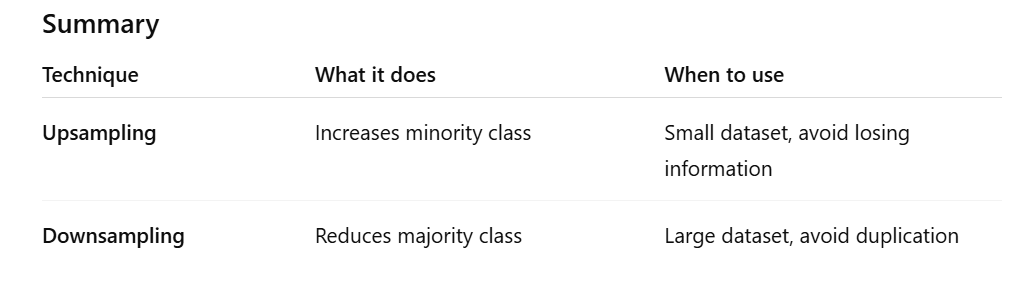

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Sample dataset
data = {
    'Age': [25, 30, 22, 28, 35],
    'Salary': [50000, 60000, 55000, 65000, 70000]
}

df2 = pd.DataFrame(data)
print("Original DataFrame:\n", df)


Original DataFrame:
    Age  Salary
0   25   50000
1   30   60000
2   22   55000
3   28   65000
4   35   70000


In [ ]:
df2

,Age,Salary
0,25,50000
1,30,60000
2,22,55000
3,28,65000
4,35,70000


#FEATURE SCALING BY USING NORMALISATION MIN MAX SCALING TECHIQUE

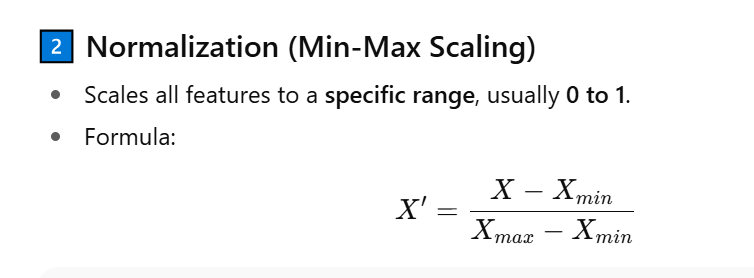

In [ ]:
# Min-Max Scaling
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

In [ ]:
print("\nNormalized DataFrame (0-1 range):\n", df_normalized)


Normalized DataFrame (0-1 range):
         Age  Salary
0  0.230769    0.00
1  0.615385    0.50
2  0.000000    0.25
3  0.461538    0.75
4  1.000000    1.00


#FEATURE SCALING BY USING STANDARDIZATION Z-SCORE SCALING  TECHNIQUE

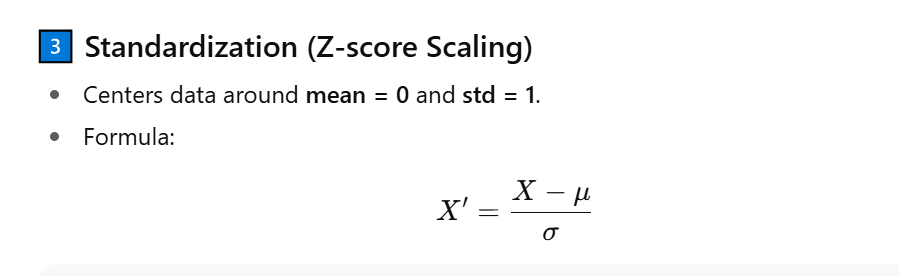

In [ ]:
# Standardization
scaler_std = StandardScaler()
df_standardized = pd.DataFrame(scaler_std.fit_transform(df), columns=df.columns)

In [ ]:
print("\nStandardized DataFrame (mean=0, std=1):\n", df_standardized)


Standardized DataFrame (mean=0, std=1):
         Age    Salary
0 -0.677631 -1.414214
1  0.451754  0.000000
2 -1.355262 -0.707107
3  0.000000  0.707107
4  1.581139  1.414214


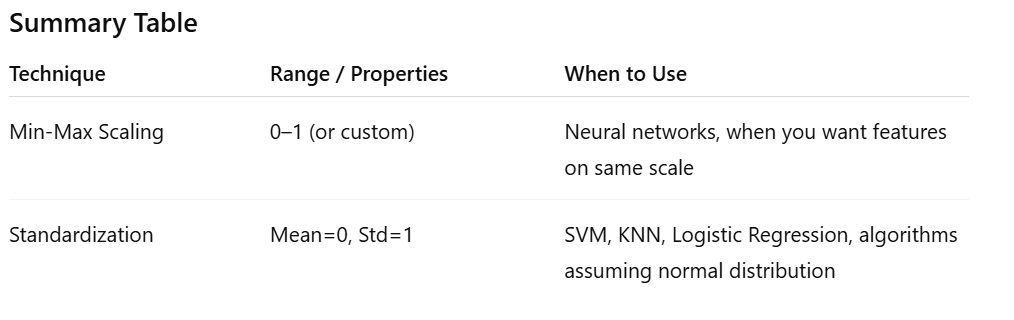